In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_FO = pd.read_csv("../FO_videos/landmarks_unnormalised_with_angles_clean.csv")
df_DTL = pd.read_csv("../DTL_frames/landmarks_unnormalised_with_angles_clean.csv")
df_coach = pd.read_csv("../FO_videos/standard_angles.csv")

# Combine both datasets
df_all = pd.concat([df_FO, df_DTL], ignore_index=True)

# Ensure consistent Position order
positions_order = sorted(df_all["Position"].unique(), key=lambda x: int(x[1:]))
df_all["Position"] = pd.Categorical(df_all["Position"], categories=positions_order, ordered=True)
df_coach["Position"] = pd.Categorical(df_coach["Position"], categories=positions_order, ordered=True)

df_all

,Unnamed: 0,Frame_Name,Person,Camera_Angle,Frame_Number,Position,shoulder_tilt_deg,hip_tilt_deg,shoulder_rotation_deg,hip_rotation_deg,forward_tilt_deg,lead_arm_deg,knee_bend_deg
0,0,eric_1_frame31.jpg,eric_1,FO,frame31,P1,8.197558,0.707686,4.654894,6.889433,80.251683,172.264613,175.208547
1,1,grant_frame115.jpg,grant,FO,frame115,P1,1.637394,0.136459,32.157195,25.424292,77.627540,169.245274,163.407155
2,2,jess_1_frame99.jpg,jess_1,FO,frame99,P1,4.649927,3.090603,1.586183,0.001108,74.145792,170.920476,166.237874
3,3,jess_2_frame230.jpg,jess_2,FO,frame230,P1,5.609975,0.141177,3.138278,7.921535,76.536985,172.457721,165.568382
4,4,nick_1_frame18.jpg,nick_1,FO,frame18,P1,12.002631,2.815969,21.235823,13.220061,68.961604,175.455967,166.324871
...,...,...,...,...,...,...,...,...,...,...,...,...,...
547,402,tom_DTL_2_frame46.jpg,tom_DTL_2,DTL,frame46,P10,30.584964,14.792249,41.243174,21.654924,21.212778,30.000337,176.633889
548,403,tom_DTL_2_frame47.jpg,tom_DTL_2,DTL,frame47,P10,27.202328,14.392284,37.592846,21.482174,20.654222,44.906837,178.411807
549,404,tom_DTL_2_frame48.jpg,tom_DTL_2,DTL,frame48,P10,24.333235,13.625731,40.151676,21.971162,19.834043,54.773147,179.405507
550,405,tom_DTL_2_frame49.jpg,tom_DTL_2,DTL,frame49,P10,22.815750,12.471228,57.635858,28.464171,19.023041,58.024128,179.976576


In [12]:
def remove_outliers_iqr(df, group_cols, angle_cols):
    df_filtered = []
    for keys, group in df.groupby(group_cols):
        g = group.copy()
        for angle in angle_cols:
            q1 = g[angle].quantile(0.25)
            q3 = g[angle].quantile(0.75)
            iqr = q3 - q1
            lower = q1 - 1.5 * iqr
            upper = q3 + 1.5 * iqr
            g = g[(g[angle] >= lower) & (g[angle] <= upper)]
        df_filtered.append(g)
    return pd.concat(df_filtered, ignore_index=True)

angle_cols = [
    "shoulder_tilt_deg", "hip_tilt_deg",
    "shoulder_rotation_deg", "hip_rotation_deg",
    "forward_tilt_deg", "lead_arm_deg", "knee_bend_deg"
]

df_all_filtered = remove_outliers_iqr(
    df_all, group_cols=["Position", "Camera_Angle"], angle_cols=angle_cols
)
df_all_filtered


C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2647880074.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for keys, group in df.groupby(group_cols):


,Unnamed: 0,Frame_Name,Person,Camera_Angle,Frame_Number,Position,shoulder_tilt_deg,hip_tilt_deg,shoulder_rotation_deg,hip_rotation_deg,forward_tilt_deg,lead_arm_deg,knee_bend_deg
0,0,eric_DTL_1_frame0.jpg,eric_DTL_1,DTL,frame0,P1,21.798826,2.617476,2.699826,5.567685,29.251613,176.063928,159.455829
1,1,eric_DTL_1_frame1.jpg,eric_DTL_1,DTL,frame1,P1,21.909740,0.557499,2.544403,5.625099,29.478743,176.918525,159.090271
2,2,eric_DTL_1_frame2.jpg,eric_DTL_1,DTL,frame2,P1,19.892327,0.080224,2.972215,6.020815,29.560191,175.066796,158.918296
3,3,eric_DTL_1_frame3.jpg,eric_DTL_1,DTL,frame3,P1,10.205283,0.911231,4.164062,6.710449,29.224312,174.998929,159.053703
4,4,eric_DTL_1_frame4.jpg,eric_DTL_1,DTL,frame4,P1,2.516386,2.459034,5.586778,7.455855,28.873608,173.608532,158.584629
...,...,...,...,...,...,...,...,...,...,...,...,...,...
357,136,rob_1a_frame500.jpg,rob_1a,FO,frame500,P10,7.592847,8.635839,85.921822,87.750917,16.595933,127.672950,167.191260
358,139,rob_1d_frame337.jpg,rob_1d,FO,frame337,P10,4.334542,14.747972,85.351375,88.247908,1.274067,126.169791,166.216452
359,140,rob_1e_frame434.jpg,rob_1e,FO,frame434,P10,14.164331,12.697320,84.400576,88.215629,7.156168,144.853704,166.468616
360,142,tom_1_frame92.jpg,tom_1,FO,frame92,P10,1.554474,0.133190,85.913110,87.700595,8.353877,91.065129,176.635376


In [13]:
# Compute summary per position and camera angle, including mean, std, min, max, median
summary = (
    df_all_filtered
    .groupby(["Position", "Camera_Angle"])[
        angle_cols
    ]
    .agg(["mean", "std", "min", "max", "median", "count"])
    .reset_index()
)

# Flatten the multi-index column names
summary.columns = ["Position", "Camera_Angle"] + [
    f"{col[0]}_{col[1]}" for col in summary.columns[2:]
]

summary

C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\1785121530.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["Position", "Camera_Angle"])[


,Position,Camera_Angle,shoulder_tilt_deg_mean,shoulder_tilt_deg_std,shoulder_tilt_deg_min,shoulder_tilt_deg_max,shoulder_tilt_deg_median,shoulder_tilt_deg_count,hip_tilt_deg_mean,hip_tilt_deg_std,...,lead_arm_deg_min,lead_arm_deg_max,lead_arm_deg_median,lead_arm_deg_count,knee_bend_deg_mean,knee_bend_deg_std,knee_bend_deg_min,knee_bend_deg_max,knee_bend_deg_median,knee_bend_deg_count
0,P1,DTL,25.980275,16.439627,0.378989,66.258933,30.643687,38,9.800428,10.067756,...,161.118517,179.994970,175.383950,38,157.633913,7.312396,145.089817,174.692480,158.726893,38
1,P1,FO,5.198098,3.130640,0.763593,9.611824,6.402969,9,2.009782,0.673205,...,172.175697,179.939792,178.965781,9,174.632764,1.922295,171.681010,176.915113,175.400829,9
2,P2,DTL,29.185878,9.278386,8.198575,40.379555,31.950940,30,13.846307,4.801785,...,166.459912,179.859769,174.278192,30,152.710221,5.917418,143.773426,169.713551,150.486011,30
3,P2,FO,11.827315,1.793123,9.145517,13.350347,12.897620,5,1.068567,0.617449,...,146.320178,158.495528,151.311855,5,178.085347,0.645414,177.444057,178.767240,177.903607,5
4,P3,DTL,38.411912,2.880812,33.513165,42.150516,39.477550,25,17.435594,2.382638,...,120.225566,174.563176,139.955721,25,145.030370,5.074711,136.042736,155.684946,143.661188,25
5,P3,FO,21.729253,12.037889,7.994534,47.760386,21.277819,10,6.536334,1.757842,...,70.510413,167.404700,144.772853,10,176.784220,1.817423,173.830869,179.530685,176.972509,10
6,P4,DTL,36.639748,3.210562,28.155130,41.008922,37.024837,29,15.779009,2.626358,...,135.570614,168.230156,151.393262,29,140.314399,4.719037,132.064179,149.257438,139.730487,29
7,P4,FO,14.618139,9.786171,0.808589,33.441679,11.939548,12,5.392345,2.085656,...,107.526064,146.456343,134.773136,12,172.937007,2.334833,168.615882,176.936053,172.942548,12
8,P5,DTL,34.002701,5.300932,17.814925,41.573270,33.888037,24,14.165818,2.094645,...,87.802266,175.932098,147.927705,24,143.873775,5.632474,135.529683,157.145507,143.105539,24
9,P5,FO,17.844981,10.865987,4.786125,39.386689,14.989260,10,7.604446,1.595193,...,134.044434,153.398122,148.392732,10,172.829330,6.655043,162.270913,179.998031,174.354781,10


C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


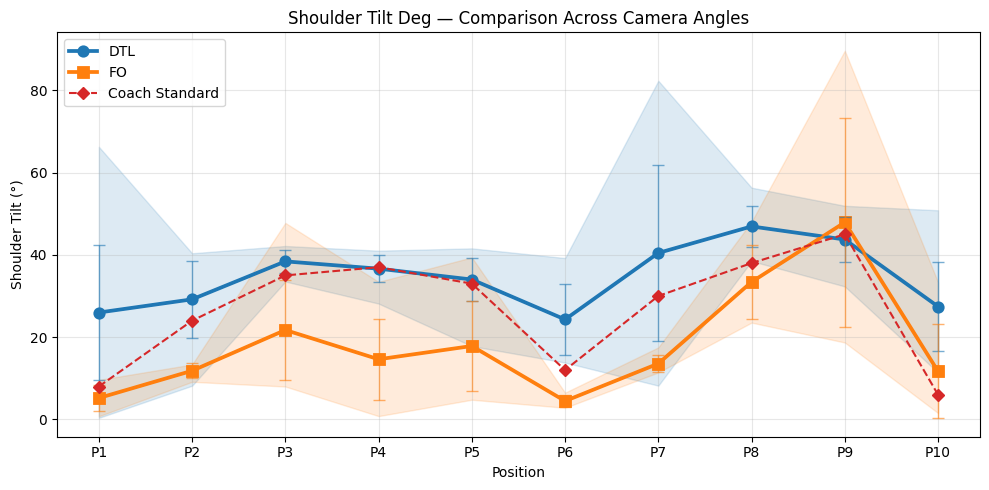

C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


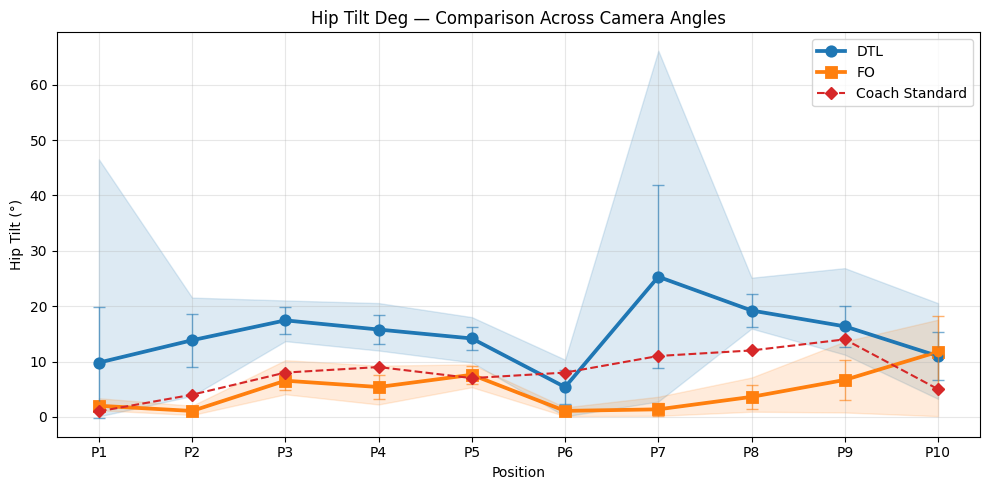

C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


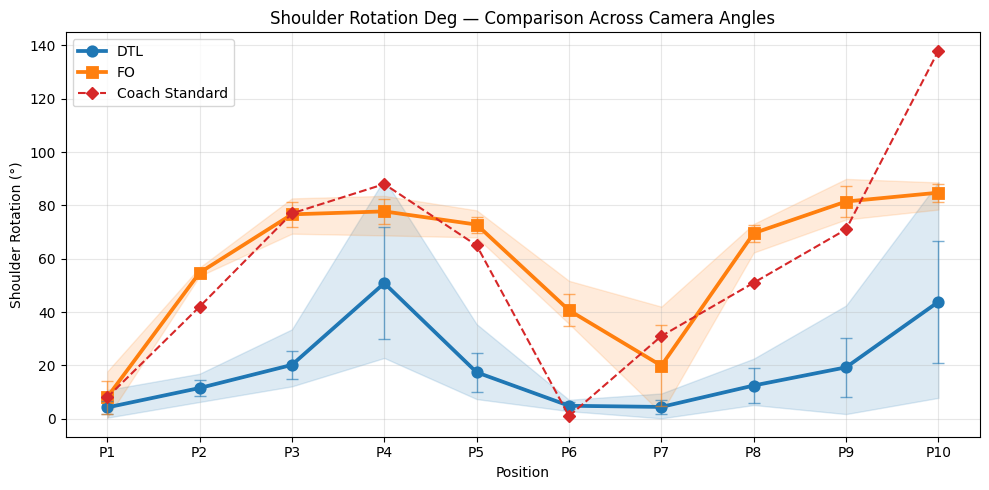

C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


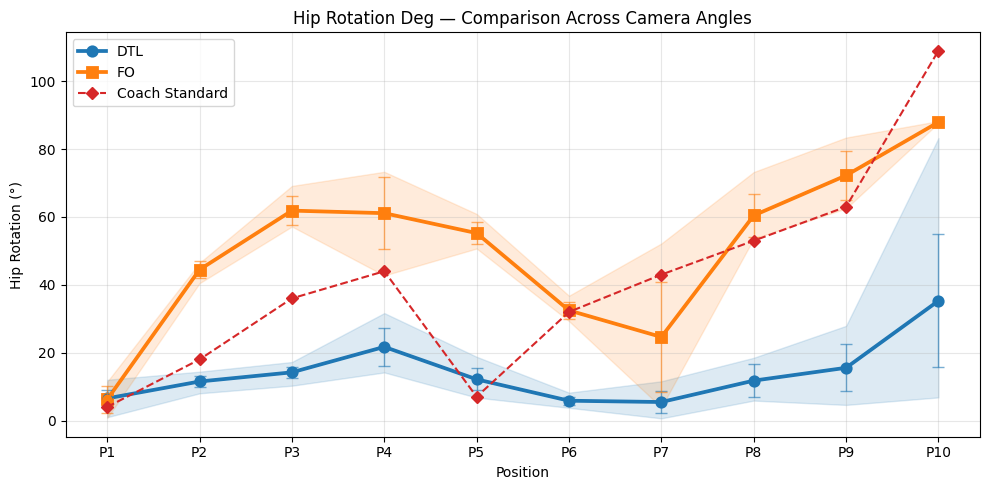

In [14]:
def plot_angle_comparison_by_camera(angle_name, ylabel=None):
    plt.figure(figsize=(10, 5))

    # Define color palette
    palette = sns.color_palette("tab10")
    camera_angles = summary["Camera_Angle"].unique()
    color_map = {cam: palette[i % len(palette)] for i, cam in enumerate(camera_angles)}

    # Plot mean lines
    sns.pointplot(
        data=summary,
        x="Position",
        y=f"{angle_name}_mean",
        hue="Camera_Angle",
        join=True,
        markers=["o", "s", "D"],
        palette=color_map,
        dodge=False
    )

    # Add per-camera shading and error bars
    for camera in camera_angles:
        subset = summary[summary["Camera_Angle"] == camera]

        plt.plot(
            subset["Position"],
            subset[f"{angle_name}_mean"],
            color=color_map[camera],
            marker="o",
        )

        plt.fill_between(
            subset["Position"],
            subset[f"{angle_name}_min"],
            subset[f"{angle_name}_max"],
            color=color_map[camera],
            alpha=0.15,
            label=None
        )

        plt.errorbar(
            subset["Position"],
            subset[f"{angle_name}_mean"],
            yerr=subset[f"{angle_name}_std"],
            fmt="none",
            ecolor=color_map[camera],
            elinewidth=1,
            alpha=0.6,
            capsize=4
        )

    # Try to plot coach benchmark if available
    coach_col = f"{angle_name.replace('_deg', '_standard')}"
    if coach_col in df_coach.columns:
        plt.plot(
            df_coach["Position"],
            df_coach[coach_col],
            color="tab:red",
            linestyle="--",
            marker="D",
            label="Coach Standard"
        )

    # Plot formatting
    plt.title(f"{angle_name.replace('_', ' ').title()} — Comparison Across Camera Angles")
    plt.xlabel("Position")
    plt.ylabel(ylabel or "Angle (°)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_angle_comparison_by_camera("shoulder_tilt_deg", "Shoulder Tilt (°)")
plot_angle_comparison_by_camera("hip_tilt_deg", "Hip Tilt (°)")
plot_angle_comparison_by_camera("shoulder_rotation_deg", "Shoulder Rotation (°)")
plot_angle_comparison_by_camera("hip_rotation_deg", "Hip Rotation (°)")

In [15]:
recommendations = []

for angle in ["shoulder_tilt_deg", "hip_tilt_deg", "shoulder_rotation_deg", "hip_rotation_deg"]:
    coach_col = f"{angle.replace('_deg', '_standard')}"
    mean_col = f"{angle}_mean"
    std_col = f"{angle}_std"

    # Merge to get coach data
    merged = summary.merge(df_coach[["Position", coach_col]], on="Position", how="left")

    # Compute absolute difference
    merged[f"{angle}_abs_diff"] = abs(merged[mean_col] - merged[coach_col])

    # Identify positions where both camera angles deviate > 5°
    deviation_check = (
        merged.groupby("Position")[f"{angle}_abs_diff"]
        .apply(lambda x: (x > 5).all())
        .rename("both_far")
    )
    merged = merged.merge(deviation_check, on="Position", how="left")

    # --- Selection logic ---
    best_rows = []
    for pos, group in merged.groupby("Position", sort=False):
        if group["both_far"].iloc[0]:
            # Both cameras too far: choose lowest variation (std)
            if std_col in group.columns and group[std_col].notna().any():
                chosen = group.loc[group[std_col].idxmin()]
            else:
                chosen = group.loc[group[f"{angle}_abs_diff"].idxmin()]
        else:
            # Normal case: choose closest to coach
            chosen = group.loc[group[f"{angle}_abs_diff"].idxmin()]
        best_rows.append(chosen)

    best = (
        pd.DataFrame(best_rows)[["Position", "Camera_Angle", f"{angle}_abs_diff"]]
        .rename(columns={
            "Camera_Angle": f"{angle}_best_camera",
            f"{angle}_abs_diff": f"{angle}_min_diff"
        })
    )

    recommendations.append(best)

# Combine all angles
camera_summary = recommendations[0]
for rec in recommendations[1:]:
    camera_summary = camera_summary.merge(rec, on="Position", how="outer")
camera_summary = (
    camera_summary
    .assign(
        pos_num=camera_summary["Position"].str.extract(r"(\d+)").astype(int)
    )
    .sort_values("pos_num")
    .drop(columns="pos_num")
    .reset_index(drop=True)
)

camera_summary


C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\4267488772.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  merged.groupby("Position")[f"{angle}_abs_diff"]
C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\4267488772.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for pos, group in merged.groupby("Position", sort=False):
C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\4267488772.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and 

,Position,shoulder_tilt_deg_best_camera,shoulder_tilt_deg_min_diff,hip_tilt_deg_best_camera,hip_tilt_deg_min_diff,shoulder_rotation_deg_best_camera,shoulder_rotation_deg_min_diff,hip_rotation_deg_best_camera,hip_rotation_deg_min_diff
0,P1,FO,2.801902,FO,1.009782,FO,0.068482,FO,2.226466
1,P2,FO,12.172685,FO,2.931433,FO,12.752218,DTL,6.498447
2,P3,DTL,3.411912,FO,1.463666,FO,0.357817,DTL,21.798630
3,P4,DTL,0.360252,FO,3.607655,FO,10.250001,DTL,22.294198
4,P5,DTL,1.002701,FO,0.604446,FO,7.792969,DTL,5.135116
5,P6,FO,7.527990,DTL,2.626162,DTL,3.871147,FO,0.447288
6,P7,FO,16.436572,FO,9.639029,DTL,26.571656,DTL,37.551031
7,P8,FO,4.590990,FO,8.385852,FO,18.577831,DTL,41.242507
8,P9,DTL,1.273444,DTL,2.351543,FO,10.451504,DTL,47.459255
9,P10,DTL,21.435776,DTL,5.976624,FO,53.229250,FO,21.059231


In [16]:
# --- Compute Z-index (standardized deviation from coach standard) ---
z_index_table = []

for angle in ["shoulder_tilt_deg", "hip_tilt_deg", "shoulder_rotation_deg", "hip_rotation_deg"]:
    coach_col = f"{angle.replace('_deg', '_standard')}"
    mean_col = f"{angle}_mean"
    std_col = f"{angle}_std"

    if std_col not in summary.columns:
        print(f"Skipping {angle}: no standard deviation column found.")
        continue

    # Merge coach standard
    merged = summary.merge(df_coach[["Position", coach_col]], on="Position", how="left")

    # Calculate Z-index for each camera (how many std devs the mean differs from coach)
    merged[f"{angle}_z_index"] = (merged[mean_col] - merged[coach_col]) / merged[std_col]

    # Keep key columns only
    z_index_table.append(
        merged[["Position", "Camera_Angle", f"{angle}_z_index"]]
    )

# Combine all Z-indexes into one wide table
z_index_summary = z_index_table[0]
for rec in z_index_table[1:]:
    z_index_summary = z_index_summary.merge(rec, on=["Position", "Camera_Angle"], how="outer")

z_index_summary = (
    z_index_summary
    .assign(pos_num=z_index_summary["Position"].str.extract(r"(\d+)").astype(int))
    .sort_values("pos_num")
    .drop(columns="pos_num")
    .reset_index(drop=True)
)

z_index_summary


,Position,Camera_Angle,shoulder_tilt_deg_z_index,hip_tilt_deg_z_index,shoulder_rotation_deg_z_index,hip_rotation_deg_z_index
0,P1,DTL,1.093716,0.874120,-1.505053,1.009602
1,P1,FO,-0.894993,1.499962,0.011107,0.573154
2,P2,DTL,0.558920,2.050552,-10.339036,-3.769144
3,P2,FO,-6.788537,-4.747655,8.774325,10.778689
4,P3,DTL,1.184358,3.960146,-11.082464,-13.275595
5,P3,FO,-1.102415,-0.832650,-0.076786,6.173838
6,P4,DTL,-0.112208,2.581144,-1.777875,-3.904217
7,P4,FO,-2.287091,-1.729746,-2.190476,1.605773
8,P5,FO,-1.394721,0.378917,2.593324,14.440854
9,P5,DTL,0.189156,3.421017,-6.493151,1.570645


In [17]:
display_cols = [
    "Position",
    "shoulder_tilt_deg_best_camera",
    "hip_tilt_deg_best_camera",
    "shoulder_rotation_deg_best_camera",
    "hip_rotation_deg_best_camera"
]
camera_summary[display_cols]

,Position,shoulder_tilt_deg_best_camera,hip_tilt_deg_best_camera,shoulder_rotation_deg_best_camera,hip_rotation_deg_best_camera
0,P1,FO,FO,FO,FO
1,P2,FO,FO,FO,DTL
2,P3,DTL,FO,FO,DTL
3,P4,DTL,FO,FO,DTL
4,P5,DTL,FO,FO,DTL
5,P6,FO,DTL,DTL,FO
6,P7,FO,FO,DTL,DTL
7,P8,FO,FO,FO,DTL
8,P9,DTL,DTL,FO,DTL
9,P10,DTL,DTL,FO,FO


# Computing other angle values

C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


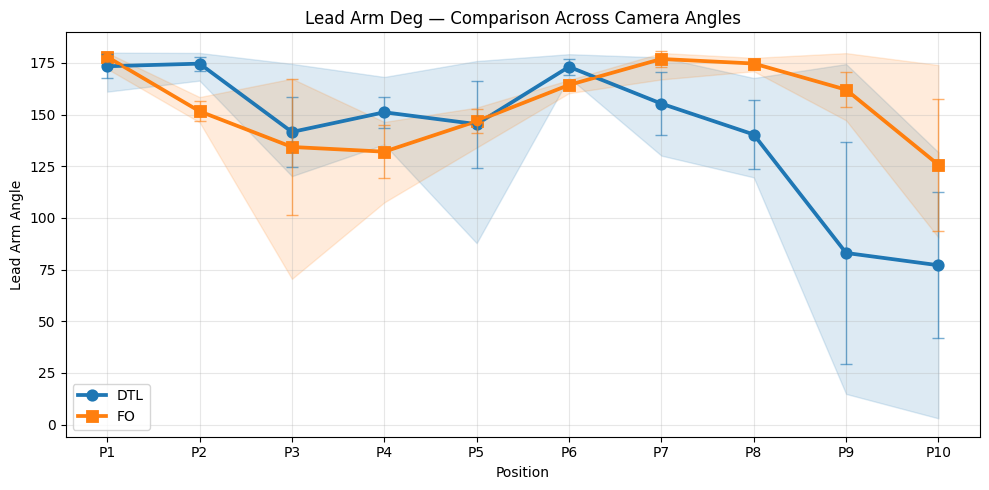

C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


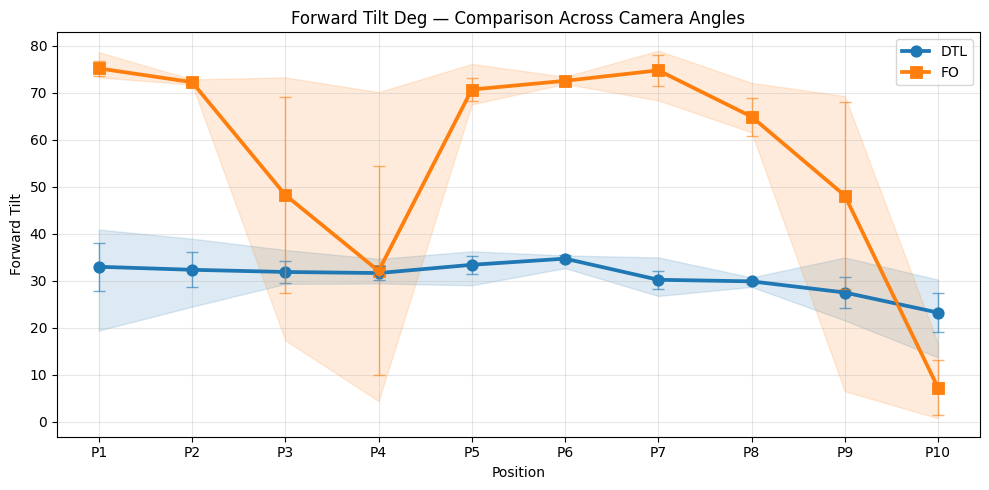

C:\Users\cryst\AppData\Local\Temp\ipykernel_11536\2047017230.py:10: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0.

  sns.pointplot(


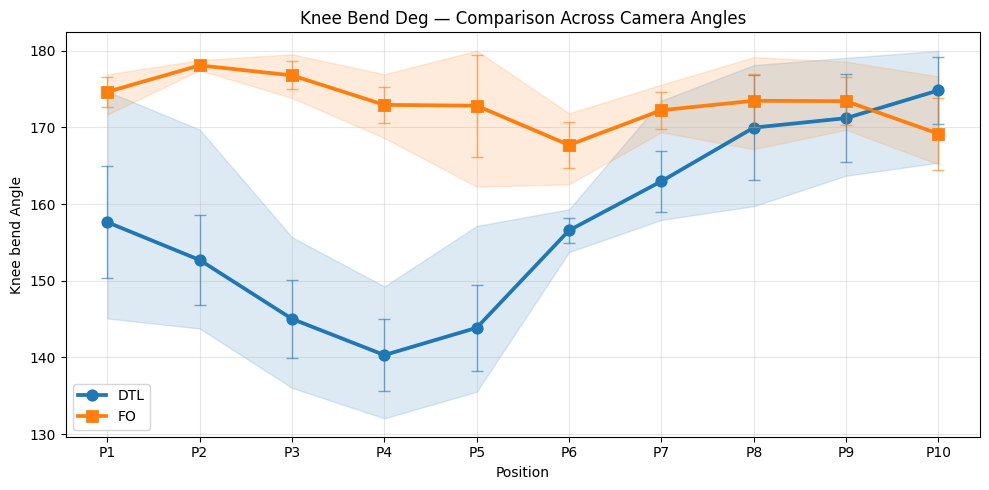

In [18]:
plot_angle_comparison_by_camera("lead_arm_deg", "Lead Arm Angle")
plot_angle_comparison_by_camera("forward_tilt_deg", "Forward Tilt")
plot_angle_comparison_by_camera("knee_bend_deg", "Knee bend Angle")

In [28]:
def plot_angle_single_camera(angle_name, camera_angle, ylabel=None):
    plt.figure(figsize=(10, 5))

    # Define color palette
    palette = sns.color_palette("tab10")
    color = palette[0]  # Use first color for the single measurement

    # Filter for specific camera angle
    subset = summary[summary["Camera_Angle"] == camera_angle]

    # Plot mean line
    plt.plot(
        subset["Position"],
        subset[f"{angle_name}_mean"],
        color=color,
        marker="o",
        linewidth=2,
        markersize=6,
        label=f"{camera_angle}"
    )

    # Add shading for min-max range
    plt.fill_between(
        subset["Position"],
        subset[f"{angle_name}_min"],
        subset[f"{angle_name}_max"],
        color=color,
        alpha=0.15
    )

    # Add error bars for standard deviation
    plt.errorbar(
        subset["Position"],
        subset[f"{angle_name}_mean"],
        yerr=subset[f"{angle_name}_std"],
        fmt="none",
        ecolor=color,
        elinewidth=1,
        alpha=0.6,
        capsize=4
    )

    # Try to plot coach benchmark if available
    coach_col = f"{angle_name.replace('_deg', '_standard')}"
    if coach_col in df_coach.columns:
        plt.plot(
            df_coach["Position"],
            df_coach[coach_col],
            color="tab:red",
            linestyle="--",
            marker="D",
            linewidth=2,
            markersize=6,
            label="Coach Standard"
        )

    # Plot formatting
    plt.title(f"{angle_name.replace('_', ' ').title()} — {camera_angle} Measurement")
    plt.xlabel("Position")
    plt.ylabel(ylabel or "Angle (°)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

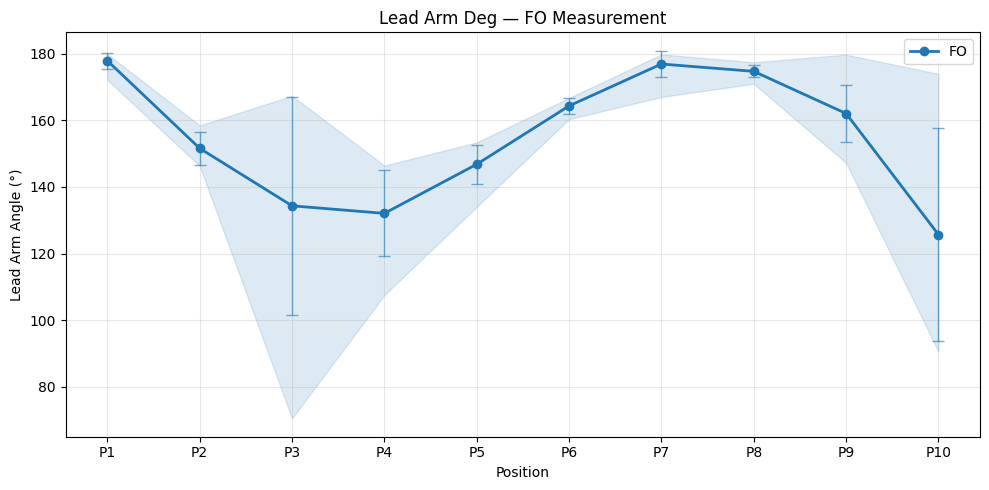

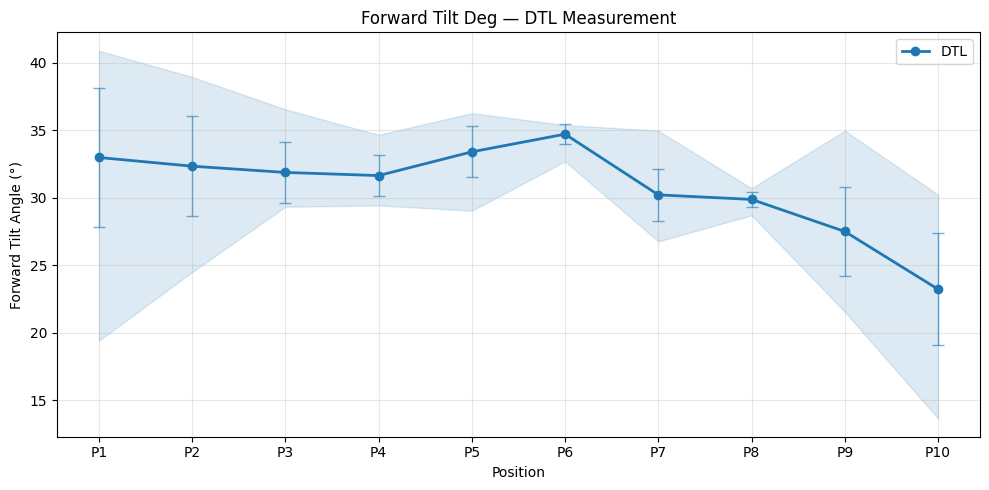

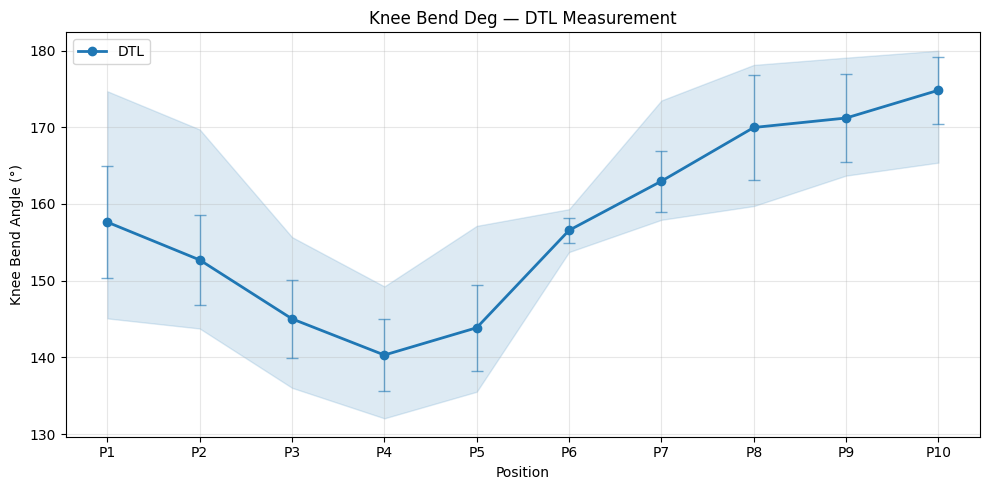

In [29]:
plot_angle_single_camera("lead_arm_deg", "FO", ylabel="Lead Arm Angle (°)")
plot_angle_single_camera("forward_tilt_deg", "DTL", ylabel="Forward Tilt Angle (°)")
plot_angle_single_camera("knee_bend_deg", "DTL", ylabel="Knee Bend Angle (°)")